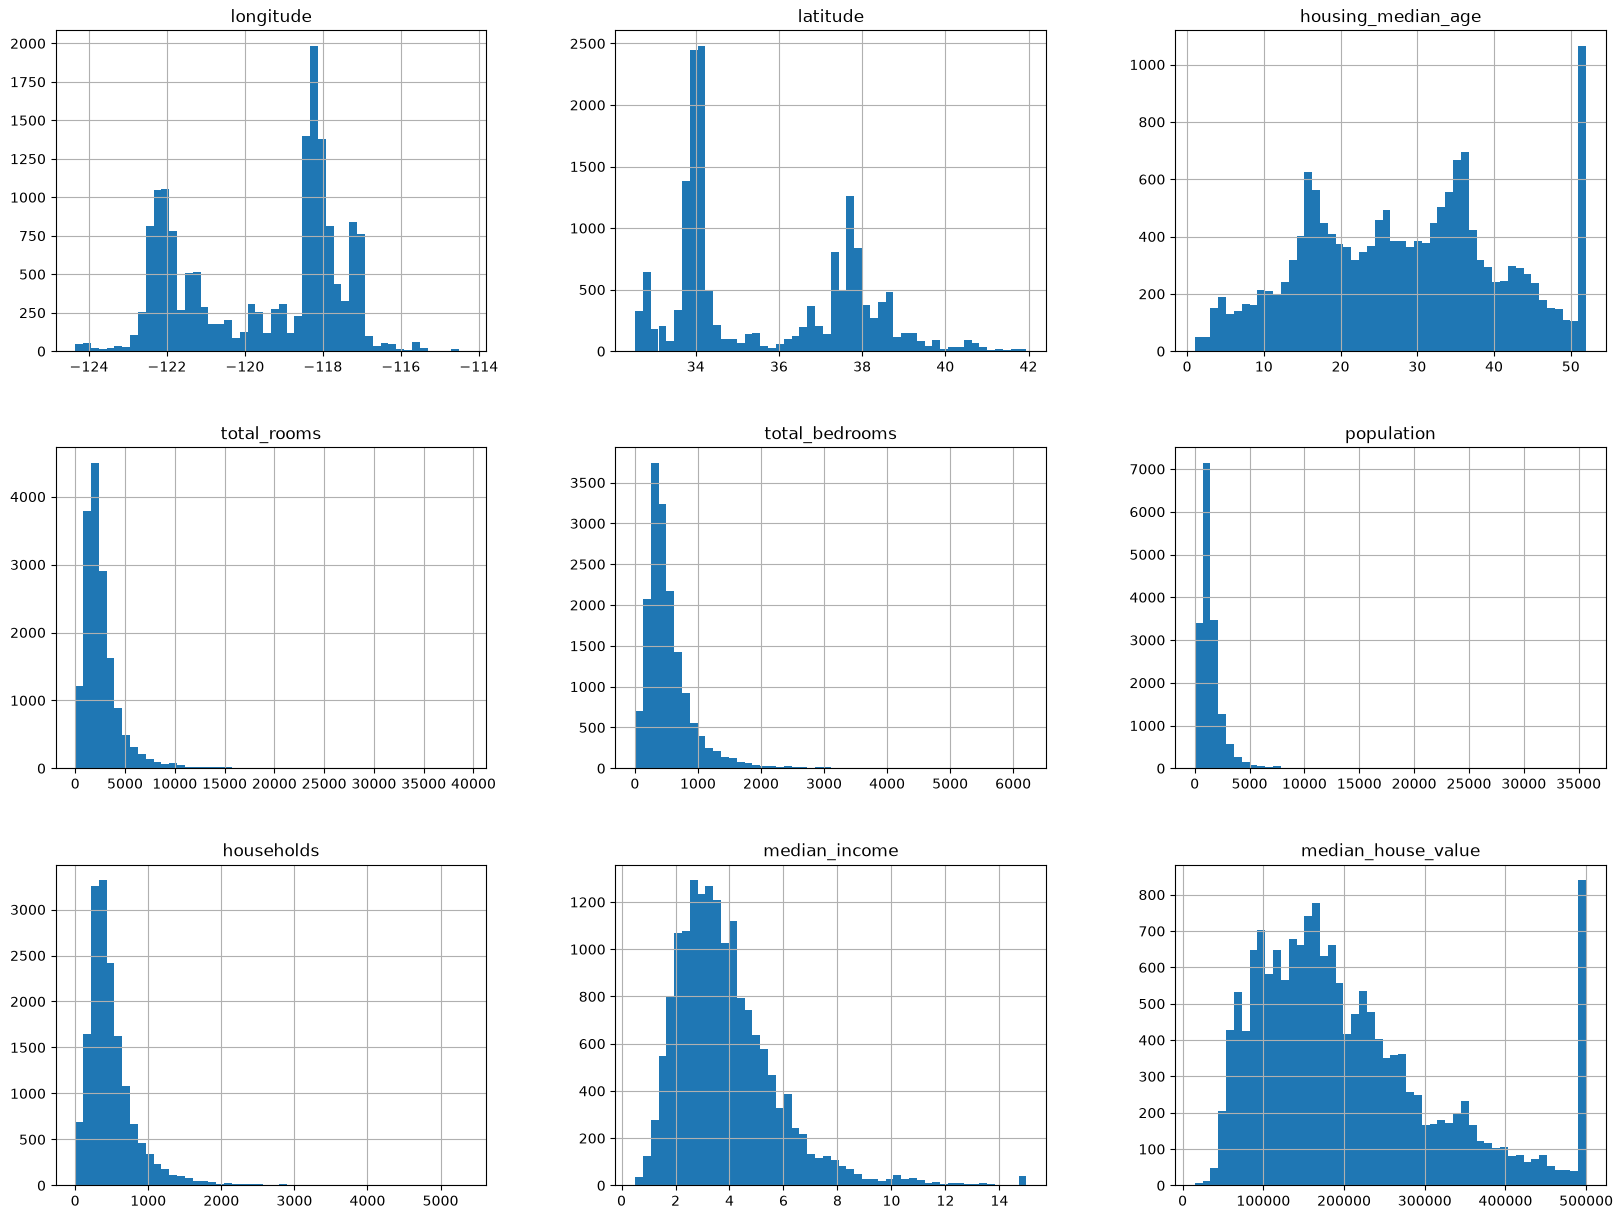

median_house_value    1.000000
median_income         0.675714
total_rooms           0.204476
households            0.110722
total_bedrooms        0.084284
housing_median_age    0.083301
population            0.001309
longitude            -0.071562
latitude             -0.162283
Name: median_house_value, dtype: float64

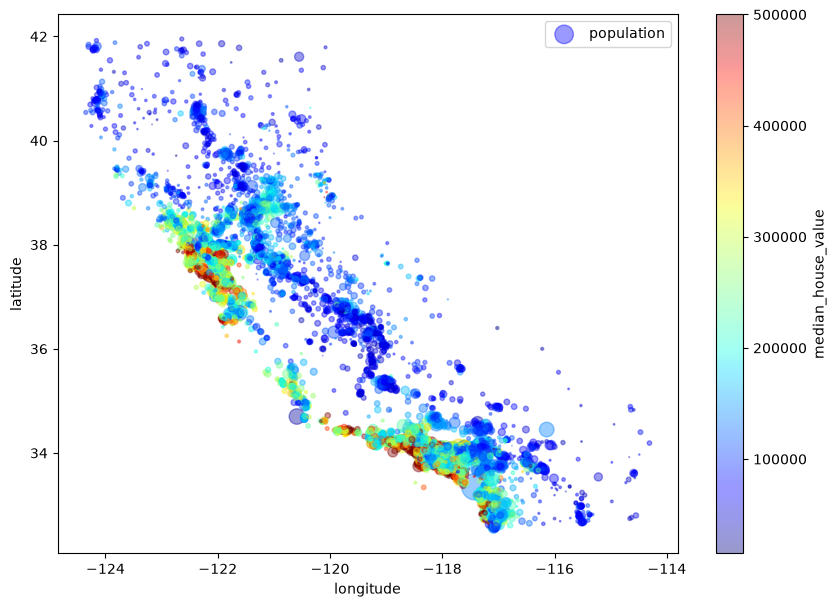

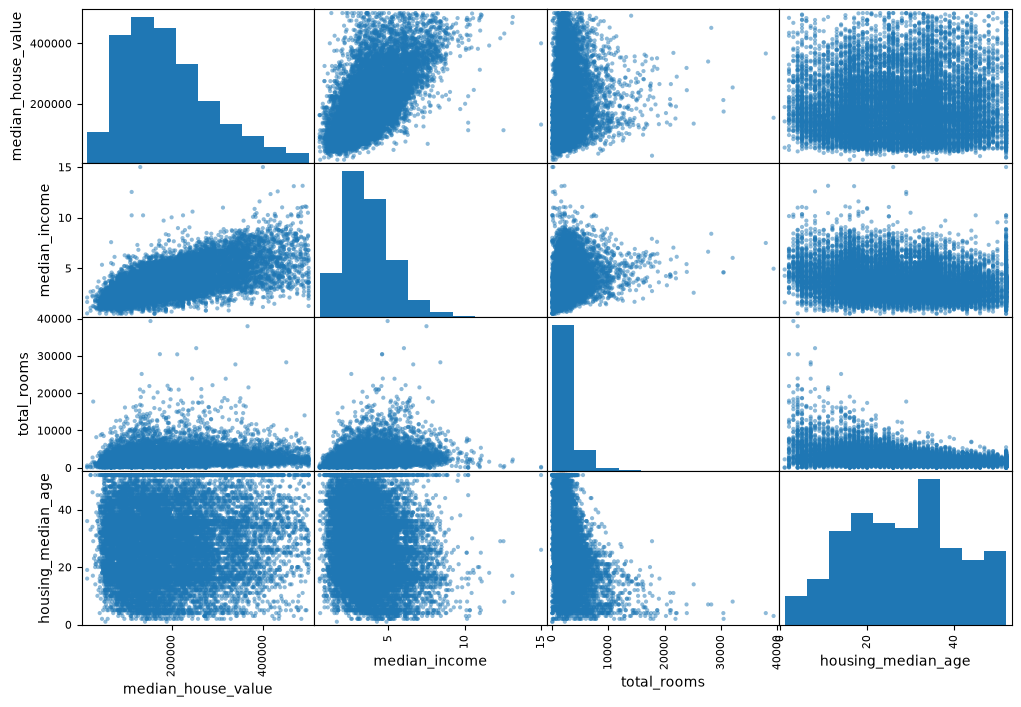

In [37]:
import pandas as pd
from pandas.plotting import scatter_matrix
import os
import hashlib
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit 
%matplotlib inline
import matplotlib.pyplot as plt
HOUSING_РАТН = os.path.join("datasets" ,"housing")
def load_housing_data(housing_path=HOUSING_РАТН):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path) 
housing = load_housing_data()

#def test_set_check(identifier, test_ratio, hash):
#    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio
#def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
#    ids = data[id_column]
#    in_test_set = ids.apply(lambda id_:test_set_check(id_, test_ratio, hash)) !random sampling!
#   return data.loc[~in_test_set], data.loc[in_test_set]
#housing_with_id = housing.reset_index()
#housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
#train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index] #!stratified sampling!
    strat_test_set = housing.loc[test_index] 
for set_ in(strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True) 

housing = strat_train_set.copy()
housing.hist(bins = 50 ,figsize = (20, 15))
plt.show()

housing.plot(kind = "scatter", x = "longitude" , y = "latitude", alpha = 0.4, s=housing["population"]/100, label = "population",
figsize = (10, 7), c = "median_house_value",
cmap = plt.get_cmap("jet"), colorbar=True)
plt.legend()

max_value = strat_train_set["median_house_value"].max()
values_to_remove = [max_value, 450000, 350000]
strat_train_set = strat_train_set[~strat_train_set["median_house_value"].isin(values_to_remove)]
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age" ]
scatter_matrix(strat_train_set[attributes], figsize= (12, 8))

corr_matrix = housing.corr(numeric_only=True, method="spearman") #!spearman helps to avoid emissions!
corr_matrix["median_house_value"].sort_values(ascending=False)